In [21]:
from pathlib import Path
from pyexpat import model
import joblib
import rsatoolbox as rsa
from tqdm import tqdm
import numpy as np
import pandas as pd
from plus_slurm import Job
import mne
import rsatoolbox as rsa
import sys
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')
from utils.subj import get_all_subjects
from utils.load_cfg import *
from utils.fusion_stat import *

# from utils.rsa import reorder_rdms
# from utils.fusion import commonality_fusion, compare_descriptors, adjust_descriptors
# from sklearn.linear_model import LinearRegression

from utils.data import masked2d_to_unmasked3d
import nibabel as nib

In [79]:
subjectID='19910703eigl'
config_class_name = 'FusionConfig_C5'

cfg = load_fusion_config_instance(config_class_name, subjectID) 
cfg.print_summary()
cfg.configure_paths()

this Fusion uses the MRI config MRIconfig_C5 and the MEG config MEGconfig_C
_______________________________________________________________________________________________________________

------MRI config Summary ------
We are using the First Level Model: > SM1C < from directory firstLevel_sensory_M1C
24 conditions were defined
Model RDM Type:     both
RDM Method:         crossnobis
RSA Method:         corr_cov
Searchlights have a radius of > 5 < voxels, with a threshold of > 1 <

------MEG config Summary ------
24 conditions were defined
Model RDM Type:     both
RDM Method:         crossnobis
RSA Method:         corr_cov
MEG cv_descriptor:  run_idx
_______________________________________________________________________________________________________________



In [80]:
file = cfg.get_outFile_names()['fusion_pkl']
data = joblib.load(file)

preStim_time = np.array(range(0, 100)) # should be adapted to dynamically find the right time points... but for now this selects times <=0
postStim_time = np.array(range(100, 200))

mask = nib.load(cfg.get_mask_file())
mask_data = mask.get_fdata()
mask_size = mask.shape

indices = np.unravel_index(data['voxel_index_py'], mask_size)
voxel_coords = np.stack(indices, axis=1)

data_4d = {
    "maskData": mask_data,
    "pre_sensory": partial_subj_data(mask_size, voxel_coords, data, preStim_time, modality="sensory", do_print=False),
    "post_sensory": partial_subj_data(mask_size, voxel_coords, data, postStim_time, modality="sensory", do_print=False),
    "pre_suprasensory": partial_subj_data(mask_size, voxel_coords, data, preStim_time, modality="suprasensory", do_print=False),
    "post_suprasensory": partial_subj_data(mask_size, voxel_coords, data, postStim_time, modality="suprasensory", do_print=False),
}

In [81]:
# group time points into bins of 10 (e.g., 0-10, 10-20, etc.) and average within each bin
results = data_4d['post_sensory']
group_size = 2
n_bins = results.shape[3] // group_size

avg_results = results.reshape(results.shape[0],
							  results.shape[1],
							  results.shape[2],
							  n_bins,
							  group_size).mean(axis=-1)

avg_results.shape   # should be (63, 76, 55, 10)

np.allclose(avg_results[:,:,:,0], np.nanmean(results[:,:,:,0:group_size], axis=-1),equal_nan=True) # sanity check

/tmp/ipykernel_508644/3075273028.py:14: RuntimeWarning: Mean of empty slice
  np.allclose(avg_results[:,:,:,0], np.nanmean(results[:,:,:,0:group_size], axis=-1),equal_nan=True) # sanity check


True

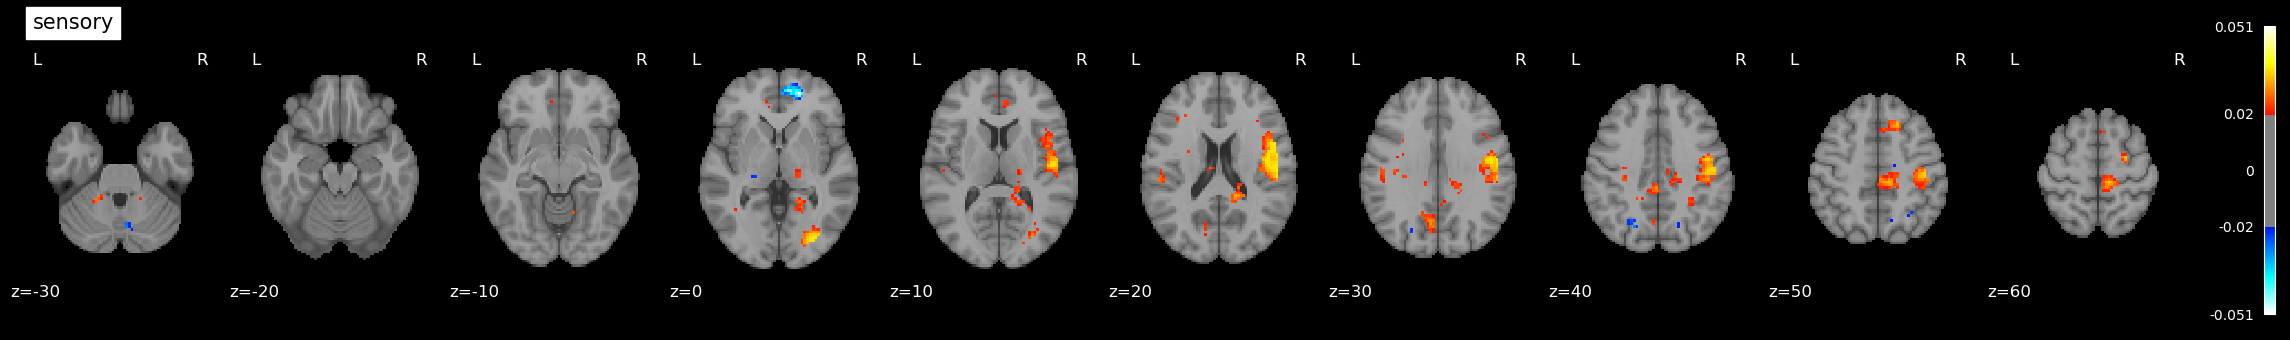

In [86]:
t = 8
overlay_img = nib.Nifti1Image(avg_results[:,:,:,t], affine = mask.affine)

plotting.plot_stat_map(
    overlay_img,
    title=f"sensory",
    threshold=0.02,  # Lower threshold to ensure visibility
	cut_coords=[-30, -20, -10, 0, 10, 20, 30, 40, 50, 60],
    display_mode='z', 
    colorbar=True,
    # vmax=1,  # Maximum value for the colorbar
    black_bg="False"
)
plotting.show()

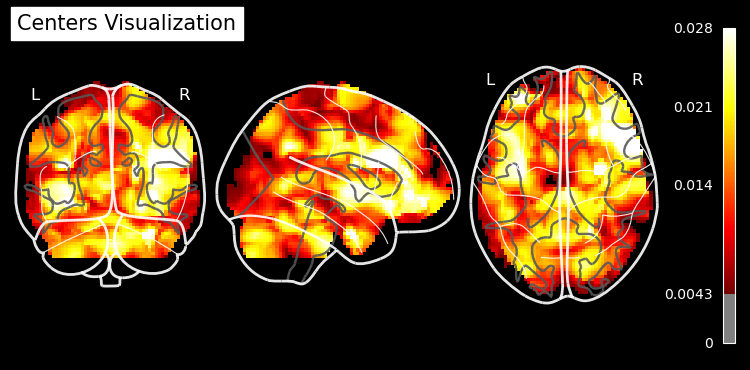

In [ ]:
preStim_time = np.array(range(0, 101)) # should be adapted to dynamicaölly find the right time points... but for now this selects times <=0
postStim_time = np.array(range(101, 200))


voxel = data['voxel_index_py']

sensory_data = [data['data'][i]['sensory'] for i in postStim_time]
suprasensory_data = [data['data'][i]['suprasensory'] for i in postStim_time]


# sensory_data = data['data'][0]['sensory']
# suprasensory_data = data['data'][0]['suprasensory']

mask = nib.load(cfg.maskFile)

overlay_data = np.zeros(mask.shape)
overlay_data[np.unravel_index(voxel, mask.shape)] = sensory_data[0]
overlay_img = nib.Nifti1Image(overlay_data, affine = mask.affine)

from nilearn import plotting
plotting.plot_glass_brain(
    overlay_img,
    bg_img=mask,  # Use the original image as the background
    title=f"sensory",
    # threshold=0.1,  # Lower threshold to ensure visibility
    display_mode="ortho",  # Orthogonal view
    colorbar=True,
    # vmax=1,  # Maximum value for the colorbar
    alpha = 0.9,
    black_bg="False"
)
plotting.show()

In [ ]:
import matplotlib

matplotlib.pyplot.hist(np.array(sensory_data), bins = 1000, range = (-5, 5))

In [19]:
type(suprasensory_data)

list